In [1]:


import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme()

# Set up matplotlib defaults for consistent plots
plt.rcParams['figure.figsize'] = (10, 6)  # Standard figure size
plt.rcParams['figure.dpi'] = 100  # Standard resolution

# Font sizes
plt.rcParams['font.size'] = 14  # Base font size
plt.rcParams['axes.titlesize'] = 22  # Plot title
plt.rcParams['axes.labelsize'] = 18  # Axis labels
plt.rcParams['xtick.labelsize'] = 14  # X-axis tick labels
plt.rcParams['ytick.labelsize'] = 14  # Y-axis tick labels
plt.rcParams['legend.fontsize'] = 18  # Legend text

# Line and marker styles
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['lines.markersize'] = 8

# Grid settings
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'

# Legend settings
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.framealpha'] = 0.8
plt.rcParams['legend.edgecolor'] = 'gray'

# Save figure settings
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = 0.2

PPO+ (Lambda=0.5) Hopper-v5
daily-valley-14
lively-puddle-15
vague-aardvark-13
honest-tree-24
solar-feather-27
PPO+ (Lambda=0.95) Hopper-v5
twilight-wave-46
fanciful-violet-49
wise-sponge-52
rose-aardvark-54
light-donkey-60
PPO+ (Lambda=0.7) Hopper-v5
lively-yogurt-30
generous-cosmos-32
astral-deluge-33
sleek-valley-39
copper-eon-44
PPO+ (Lambda=0.) Hopper-v5
northern-donkey-3
bright-brook-4
young-yogurt-11
silvery-flower-8
soft-resonance-18
PPO+ (Lambda=0.5) Walker2d-v5
mild-jazz-16
lilac-disco-20
glamorous-morning-22
daily-waterfall-28
robust-lake-31
PPO+ (Lambda=0.95) Walker2d-v5
silver-sponge-47
desert-lake-48
blooming-yogurt-50
generous-puddle-53
neat-disco-58
PPO+ (Lambda=0.7) Walker2d-v5
silver-resonance-34
misunderstood-morning-35
kind-star-36
magic-morning-41
cosmic-meadow-42
PPO+ (Lambda=0.) Walker2d-v5
scarlet-haze-2
autumn-bird-2
absurd-glitter-10
jumping-snowball-11
clean-brook-17
PPO+ (Lambda=0.5) HalfCheetah-v5
fluent-feather-21
rare-surf-23
amber-eon-25
fresh-cherry-26


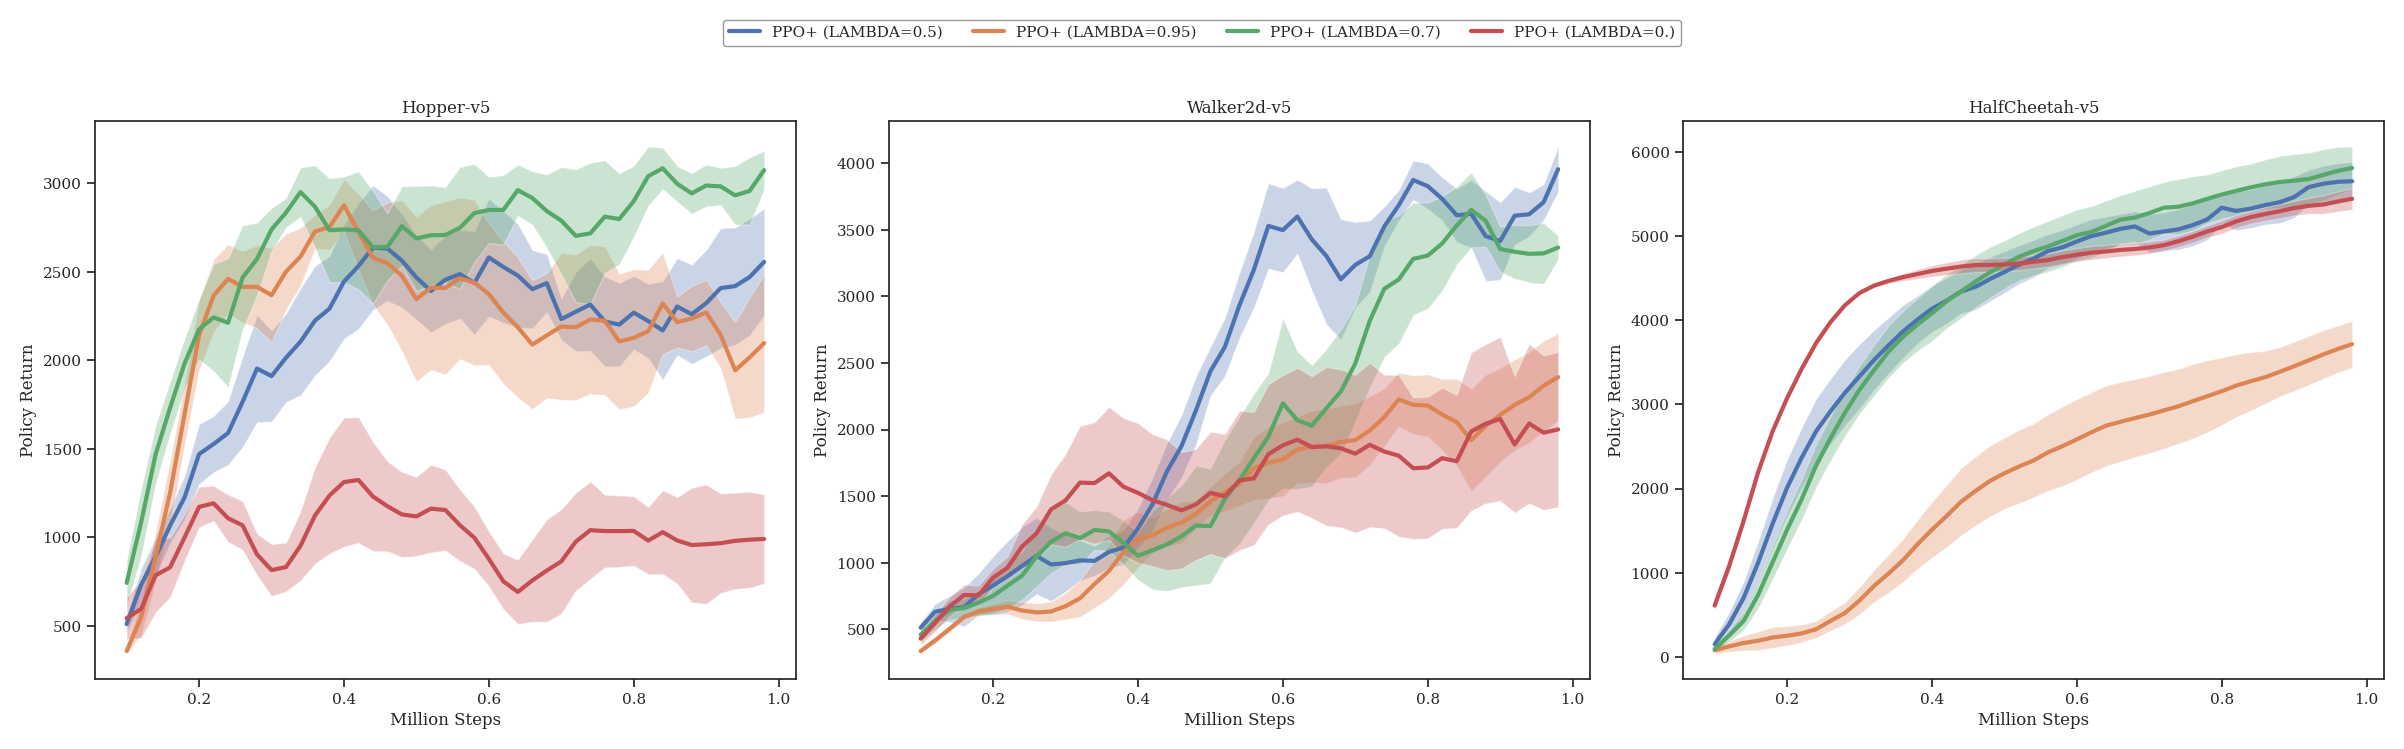

In [3]:
import pandas as pd
import wandb
import os
import numpy as np
import itertools





os.environ["WANDB_API_KEY"]="28996bd59f1ba2c5a8c3f2cc23d8673c327ae230"
api = wandb.Api()
entity  = "mahdikallel"
runs = api.runs(entity + "/" + "GAE_LAMBDA_ABLATIONS")





def filter_fn(run,env_name, filter_dict):

    
    if run.config["env_name"]==env_name:
        for key, value in filter_dict.items():
            if key not in run.config or run.config[key] != value:
                return False
        return True
    return False



dc = { 
        "PPO+ (Lambda=0.5)":{"algo_name":"superppo","gamma":0.99,"on_policy_data":False,"temperature":1.,"buffer_size":50000,"use_layer_norm":True,"clipping_ratio":0.25,"num_critics":2,"bound_actions":True,"gae_lambda":0.5,"min_target":False},
        "PPO+ (Lambda=0.95)":{"algo_name":"superppo","gamma":0.99,"on_policy_data":False,"temperature":1.,"buffer_size":50000,"use_layer_norm":True,"clipping_ratio":0.25,"num_critics":2,"bound_actions":True,"gae_lambda":0.95,"min_target":False},
        "PPO+ (Lambda=0.7)":{"algo_name":"superppo","gamma":0.99,"on_policy_data":False,"temperature":1.,"buffer_size":50000,"use_layer_norm":True,"clipping_ratio":0.25,"num_critics":2,"bound_actions":True,"gae_lambda":0.7,"min_target":False},
        "PPO+ (Lambda=0.)":{"algo_name":"superppo","gamma":0.99,"on_policy_data":False,"temperature":1.,"buffer_size":50000,"use_layer_norm":True,"clipping_ratio":0.25,"num_critics":2,"bound_actions":True,"gae_lambda":0.,"min_target":False},
       
}
      
      
# dc = { 
#         "PPO (Lambda=0.5)":{"algo_name":"ppo","gamma":0.99,"gae_lambda":0.5},
#         "PPO (Lambda=0.95)":{"algo_name":"ppo","gamma":0.99,"gae_lambda":0.95},
#         "PPO (Lambda=0.7)":{"algo_name":"ppo","gamma":0.99,"gae_lambda":0.7},
#         "PPO (Lambda=0.)":{"algo_name":"ppo","gamma":0.99,"gae_lambda":0.},
       
# }
      
env_names = ["Hopper-v5","Walker2d-v5","HalfCheetah-v5"]
max_steps = [1e6,1e6,1e6]

fig, axs = plt.subplots(1, 3, figsize=(24, 7))
# Reset runs chain for the outer loop
for ax, env_name, max_step in zip(axs.flatten(), env_names, max_steps):
    # Reset the runs chain for each environment
    
    
    for algo in dc.keys():
        print(algo, env_name)
        
        df = pd.DataFrame()
        config_list, name_list, run_list = [], [], []
        for run in runs:
            if filter_fn(run, env_name, dc[algo]):
                
                config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
                name_list.append(run.name)
                full_df = run.history(samples=10000)
                tmp_df = full_df[['evaluation/undisc_policy_return', '_step']].dropna(axis=0)
                window = 1 if env_name == "InvertedDoublePendulum-v5" else 5
                tmp_df["average return"] = tmp_df['evaluation/undisc_policy_return'].rolling(window=window).mean()
                tmp_df['step'] = np.round(tmp_df['_step'] / 10000) * 10000
                tmp_df = tmp_df[["step", "average return"]]
                df = pd.concat([df, tmp_df], ignore_index=True)
                print(run.name)
                
        df2 = df[df["step"] < int(max_step)]
        x = df2.groupby("step")["step"].mean() / 1e6
        mean = df2.groupby("step")["average return"].mean()
        stderror = df2.groupby("step")["average return"].std() / np.sqrt(df2.groupby("step")["average return"].count())
        
        ax.plot(x, mean, label=algo.upper(), linewidth=3)
        ax.fill_between(x, mean - stderror, mean + stderror, alpha=0.3)
        ax.set_xlabel('Million Steps')
        ax.set_ylabel('Policy Return')
        ax.set_title(env_name)
        
        # Reset runs chain for the next algorithm
        runs = api.runs(entity + "/" + "GAE_LAMBDA_ABLATIONS")
        

# Create one common legend on top of the figure
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(dc.keys()), bbox_to_anchor=(0.5, 1.05))
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("./plots/benchmarks/lambda_ppo_plus.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [ ]:
import pandas as pd
import wandb
import os
import numpy as np
import itertools





os.environ["WANDB_API_KEY"]="28996bd59f1ba2c5a8c3f2cc23d8673c327ae230"
api = wandb.Api()
entity, project_ppo,project_ppo_plus = "mahdikallel", "RLC_PPO_OURS", "PPO_PLUS_FINAL"
runs_ppo_plus = api.runs(entity + "/" + "PPO_PLUS_SUPER_A40")
runs_ppo = api.runs(entity + "/" + "RLC_PPO_OURS")
runs_sac = api.runs(entity + "/" + "sac_benchmark2")
runs_trpo = api.runs("joseluisholgado/TRPO-LOCOMOTION-ENVS-MAHDI-CONF")

runs = itertools.chain(runs_ppo_plus,runs_ppo,runs_sac,runs_trpo)




def filter_fn(run,env_name, filter_dict):

    
    if run.config["env_name"]==env_name:
        for key, value in filter_dict.items():
            if key not in run.config or run.config[key] != value:
                return False
        return True
    return False



dc = { 
        "PPO+":{"algo_name":"superppo","gamma":0.99,"on_policy_data":False,"temperature":1.,"buffer_size":50000,"use_layer_norm":True,"clipping_ratio":0.25,"num_critics":2,"bound_actions":True,"gae_lambda":0.5,"min_target":False},
        "PPO":{"algo_name":"ppo","gamma":0.99},
        "PPO(ours)":{"algo_name":"ppo_ours","gamma":0.99},
        "SAC":{"algo_name":"sac","gamma":0.99},
        "TRPO": {"algo_name":"trpo"}
}
      
      
env_names = ["InvertedDoublePendulum-v5","Hopper-v5","Walker2d-v5","HalfCheetah-v5","Ant-v5","Humanoid-v5"]
max_steps = [2e5,1e6,1e6,1e6,1e6,5e6]

fig, axs = plt.subplots(2, 3, figsize=(24, 12))
# Reset runs chain for the outer loop
for ax, env_name, max_step in zip(axs.flatten(), env_names, max_steps):
    # Reset the runs chain for each environment
    runs = itertools.chain(runs_ppo_plus, runs_ppo, runs_sac, runs_trpo)
    
    for algo in dc.keys():
        print(algo, env_name)
        
        df = pd.DataFrame()
        config_list, name_list, run_list = [], [], []
        for run in runs:
            if filter_fn(run, env_name, dc[algo]):
                
                config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
                name_list.append(run.name)
                full_df = run.history(samples=10000)
                tmp_df = full_df[['evaluation/undisc_policy_return', '_step']].dropna(axis=0)
                window = 1 if env_name == "InvertedDoublePendulum-v5" else 5
                tmp_df["average return"] = tmp_df['evaluation/undisc_policy_return'].rolling(window=window).mean()
                tmp_df['step'] = np.round(tmp_df['_step'] / 10000) * 10000
                tmp_df = tmp_df[["step", "average return"]]
                df = pd.concat([df, tmp_df], ignore_index=True)
                print(run.name)
                
        df2 = df[df["step"] < int(max_step)]
        x = df2.groupby("step")["step"].mean() / 1e6
        mean = df2.groupby("step")["average return"].mean()
        stderror = df2.groupby("step")["average return"].std() / np.sqrt(df2.groupby("step")["average return"].count())
        
        ax.plot(x, mean, label=algo.upper(), linewidth=3)
        ax.fill_between(x, mean - stderror, mean + stderror, alpha=0.3)
        ax.set_xlabel('Million Steps')
        ax.set_ylabel('Policy Return')
        ax.set_title(env_name)
        
        # Reset runs chain for the next algorithm
        runs = itertools.chain(runs_ppo_plus, runs_ppo, runs_sac, runs_trpo)
        

# Create one common legend on top of the figure
handles, labels = axs[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(dc.keys()), bbox_to_anchor=(0.5, 1.05))
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("./plots/benchmarks/benchmark.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [ ]:
import pandas as pd
import wandb
import os
import numpy as np
import itertools



os.environ["WANDB_API_KEY"]="28996bd59f1ba2c5a8c3f2cc23d8673c327ae230"
api = wandb.Api()
entity, project_ppo,project_ppo_plus = "mahdikallel", "RLC_PPO_OURS", "PPO_PLUS_FINAL"
runs_ppo_plus = api.runs(entity + "/" + "PPO_PLUS_SUPER_A40")

runs = itertools.chain(runs_ppo_plus)



def filter_fn(run,env_name, filter_dict):

    
    if run.config["env_name"]==env_name:
        for key, value in filter_dict.items():
            if key not in run.config or run.config[key] != value:
                return False
        return True
    return False



dc = { 
        "PPO+":{"algo_name":"superppo","gamma":0.99,"on_policy_data":False,"temperature":1.,"buffer_size":50000,"use_layer_norm":True,"clipping_ratio":0.25,"num_critics":2,"bound_actions":True,"gae_lambda":0.5,"min_target":False},
        "Unbounded actions":{"algo_name":"superppo","gamma":0.99,"on_policy_data":False,"temperature":1.,"buffer_size":50000,"use_layer_norm":True,"clipping_ratio":0.25,"num_critics":2,"bound_actions":False,"gae_lambda":0.5,"min_target":False},
        "On policy critic":{"algo_name":"superppo","gamma":0.99,"on_policy_data":True,"temperature":1.,"buffer_size":5000,"use_layer_norm":True,"clipping_ratio":0.25,"num_critics":2,"bound_actions":True,"gae_lambda":0.5,"min_target":False},
        "No entropy":{"algo_name":"superppo","gamma":0.99,"on_policy_data":False,"temperature":0.,"buffer_size":50000,"use_layer_norm":True,"clipping_ratio":0.25,"num_critics":2,"bound_actions":True,"gae_lambda":0.5,"min_target":False},
        "No LayerNorm ":{"algo_name":"superppo","gamma":0.99,"on_policy_data":False,"temperature":1.,"buffer_size":50000,"use_layer_norm":False,"clipping_ratio":0.25,"num_critics":2,"bound_actions":True,"gae_lambda":0.5},
}
      
      

legends = [""]
env_names = ["InvertedDoublePendulum-v5","Hopper-v5","Walker2d-v5","HalfCheetah-v5","Ant-v5","Humanoid-v5"]
#env_names =  ["Hopper-v5"]
max_steps = [2e5,1e6,1e6,1e6,1e6,5e6]
legend = [True,False,False,False,False,False]



fig, axs = plt.subplots(2, 3, figsize=(24, 12))
# Reset runs chain for the outer loop
for ax, env_name, max_step in zip(axs.flatten(), env_names, max_steps):


    for algo in dc.keys():
        
            print(algo,env_name)
            
            df = pd.DataFrame()
            config_list, name_list,run_list= [], [],[]
            count = 0
            for run in runs:
                if filter_fn(run,env_name,dc[algo]):
                    
                    count += 1
                    
                    config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
                    # .name is the human-readable name of the run.
                    name_list.append(run.name)
                    full_df = run.history(samples=10000)
                    tmp_df = full_df[['evaluation/undisc_policy_return','_step']].dropna(axis=0)
                    window = 1 if env_name == "InvertedDoublePendulum-v5" else 5
                    tmp_df["average return"] = tmp_df['evaluation/undisc_policy_return'].rolling(window=window).mean()
                    tmp_df['step'] = np.round(tmp_df['_step'] / 10000) * 10000
                    tmp_df = tmp_df[["step","average return"]]
                    df = pd.concat([df, tmp_df], ignore_index=True)
                    print(run.name)
                    
                    #print("DF_TEMP",df)
                
                if count == 5:
                    break



            #runs_df = pd.DataFrame({"config": config_list, "name": name_list})
            #print(df)
            df2 = df[df["step"]<int(max_step)]
            x = df2.groupby("step")["step"].mean()/1e6
            mean = df2.groupby("step")["average return"].mean()
            stderror = df2.groupby("step")["average return"].std()/np.sqrt(df2.groupby("step")["average return"].count())
            #stderror = df2.groupby("step")["average return"].std()
  
            ax.plot(x, mean, label=algo.upper(), linewidth=3)
            ax.fill_between(x, mean - stderror, mean + stderror, alpha=0.3)
            ax.set_xlabel('Million Steps')
            ax.set_ylabel('Policy Return')
            ax.set_title(env_name)
            runs = itertools.chain(runs_ppo_plus)
            #runs = runs_sac

# Create one common legend on top of the figure
handles, labels = axs[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(dc.keys()), bbox_to_anchor=(0.5, 1.05))
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("./plots/ablations/ablation1.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [ ]:
# import wandb
# api = wandb.Api()
# entity = "mahdikallel"
# project_name = "sac_benchmark2"
# runs = api.runs(entity + "/" + project_name)

# for run in runs:
#     print(f"Updating run: {run.name}")
#     # Copy the existing configuration and add the new entry
    
#     #run.config["env_name"] = run.config["_fields"]["env_name"]
#     run.config["gamma"]=0.99
#     # Update the run config. Note: Updating finished runs may be restricted.
#     run.update()

Fetching runs from project: mahdikallel/AAAI_GRAD_2000

--- Processing Config: InvertedDoublePendulum ---
Found 6 runs for config: {'env_name': 'InvertedDoublePendulum-v5'}

--- Processing Config: Hopper ---
Found 6 runs for config: {'env_name': 'Hopper-v5'}

--- Processing Config: Walker2d ---
Found 5 runs for config: {'env_name': 'Walker2d-v5'}

--- Processing Config: HalfCheetah ---
Found 5 runs for config: {'env_name': 'HalfCheetah-v5'}

--- Processing Config: Ant ---
Found 5 runs for config: {'env_name': 'Ant-v5'}

--- Processing Config: Humanoid ---
Found 5 runs for config: {'env_name': 'Humanoid-v5'}

Saving final plot to ./gradient_comparison_styled.pdf


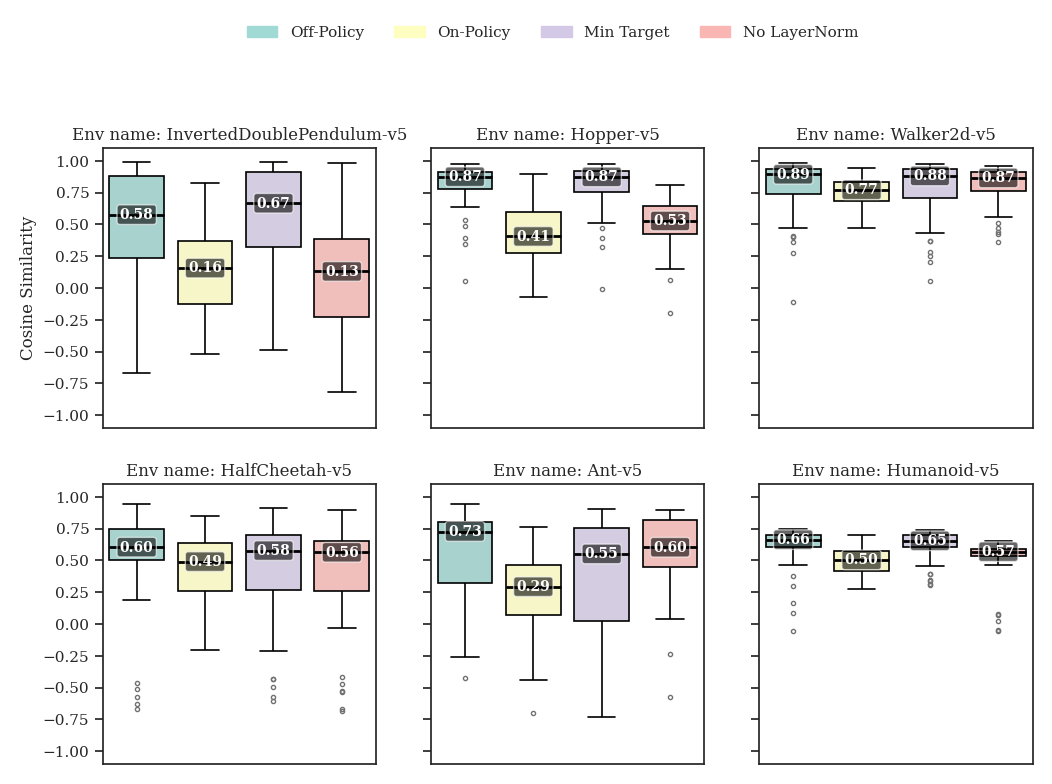

In [7]:
import pandas as pd
import wandb
import os
import numpy as np

# --- Configuration ---

# Set your W&B API key. Best practice is to set this as an environment variable.
# os.environ["WANDB_API_KEY"] = "YOUR_API_KEY"

# --- W&B API Setup ---

try:
    api = wandb.Api()
except wandb.errors.ApiException as e:
    print(f"Failed to connect to W&B API. Please check your API key. Error: {e}")
    exit()

# Define the W&B project path
ENTITY = "mahdikallel"
PROJECT = "AAAI_GRAD_2000"
PROJECT_PATH = f"{ENTITY}/{PROJECT}"

# Define the different configurations to plot. These will be our subplots.
CONFIGS = {
    "InvertedDoublePendulum": {"env_name": "InvertedDoublePendulum-v5"},
    "Hopper": {"env_name": "Hopper-v5"},
    "Walker2d": {"env_name": "Walker2d-v5"},
    "HalfCheetah": {"env_name": "HalfCheetah-v5"},
    "Ant": {"env_name": "Ant-v5"},
    "Humanoid": {"env_name": "Humanoid-v5"},  
}

# Define the metrics to be extracted. The order here is important and must match
# the labels and colors defined below.
METRICS = [
    "train/cosine_true_normal", # Corresponds to "Off-Policy"
    "train/cosine_true_on",     # Corresponds to "On-Policy"
    "train/cosine_true_min",    # Corresponds to "Min Target"
    "train/cosine_true_no",     # Corresponds to "No LayerNorm"
]

# --- Aesthetics Configuration to Match Example Image ---

# Define the labels for the legend and the categories
LEGEND_LABELS = ["Off-Policy", "On-Policy", "Min Target", "No LayerNorm"]

# Define a custom color palette to match the example image
# Colors in order: Light Teal, Light Yellow, Light Purple, Light Red/Salmon
CUSTOM_PALETTE = ["#a1d9d4", "#fefec1", "#d3c9e6", "#f9b6b2"]


# --- Helper Functions ---

def fetch_and_filter_runs(project_path, config_params):
    """Fetches and filters W&B runs based on config parameters."""
    all_runs = api.runs(project_path)
    matching_runs = [
        run for run in all_runs
        if all(run.config.get(key) == value for key, value in config_params.items())
    ]
    print(f"Found {len(matching_runs)} runs for config: {config_params}")
    return matching_runs

def get_data_for_config(runs, metrics, max_step):
    """Processes a list of runs to extract and combine their history data."""
    df_list = []
    for run in runs:
        try:
            history_df = run.history(samples=20000, keys=metrics + ['_step'])
            tmp_df = history_df.dropna(axis=0)
            tmp_df = tmp_df[tmp_df["_step"] < int(max_step)]
            if not tmp_df.empty:
                df_list.append(tmp_df[metrics])
        except Exception as e:
            print(f"Warning: Could not process history for run '{run.name}'. Error: {e}")
    
    return pd.concat(df_list, ignore_index=True) if df_list else None


# --- Main Plotting Script ---

if __name__ == "__main__":
    # Set the overall theme to be simple and clean
    sns.set_theme(style="ticks", rc={"font.family": "serif"})
    
    MAX_STEP_LIMIT = 1_000_000
    
    # Create a figure with 3 subplots, arranged in 1 row and 3 columns
    fig, axs = plt.subplots(2, 3, figsize=(12, 8), sharey=True)
    
    print(f"Fetching runs from project: {PROJECT_PATH}")

    # Iterate through each configuration and its corresponding subplot axis
    for ax, (config_name, config_params) in zip(axs.flatten(), CONFIGS.items()):
        print(f"\n--- Processing Config: {config_name} ---")
        
        matching_runs = fetch_and_filter_runs(PROJECT_PATH, config_params)
        if not matching_runs:
            ax.text(0.5, 0.5, "No data found", ha='center', va='center')
            continue
            
        plot_data = get_data_for_config(matching_runs, METRICS, MAX_STEP_LIMIT)
        if plot_data is None or plot_data.empty:
            ax.text(0.5, 0.5, "No valid data", ha='center', va='center')
            continue
            
        # Ensure the data columns are in the correct order for plotting
        plot_data = plot_data[METRICS]
        
        # Generate the boxplot with custom styling
        sns.boxplot(
            data=plot_data,
            ax=ax,
            palette=CUSTOM_PALETTE,
            showfliers=True, # Show outliers as in the example
            fliersize=3,
            linewidth=1.2,
            medianprops={'color': 'black', 'linewidth': 2},
            whiskerprops={'color': 'black', 'linewidth': 1.2},
            capprops={'color': 'black', 'linewidth': 1.2},
            boxprops={'edgecolor': 'black'}
        )
        
        # Add median value labels inside the boxes, styled like the example
        medians = plot_data.median()
        for i, median_val in enumerate(medians):
            ax.text(
                i, median_val, f'{median_val:.2f}',
                ha='center', va='center',
                color='white',
                fontsize=10,
                fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.6, pad=2, boxstyle='round,pad=0.2')
            )
            
        # --- Subplot Styling ---
        ax.set_title(f"Env name: {config_params['env_name']}", fontsize=12)
        # Remove x-axis labels and ticks as per the example
        ax.set_xlabel('')
        ax.set_xticks([])
        # Set y-axis limits
        ax.set_ylim(-1.1, 1.1)

    # --- Global Figure Styling ---
    
    # Set a shared y-axis label for the leftmost plot
    axs[0,0].set_ylabel('Cosine Similarity', fontsize=12)
    
    # Create custom legend handles (patches) for the categories
    legend_patches = [
        mpatches.Patch(color=color, label=label)
        for color, label in zip(CUSTOM_PALETTE, LEGEND_LABELS)
    ]
    
    # Add the shared, horizontal legend to the top of the figure
    fig.legend(
        handles=legend_patches,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.05), # Position it above the plots
        ncol=len(LEGEND_LABELS),   # Make it horizontal
        frameon=False,             # No border around the legend
        fontsize=11
    )
    
    # handles, labels = axs[0,0].get_legend_handles_labels()
    # fig.legend(handles, labels, loc='upper center', ncol=len(LEGEND_LABELS), bbox_to_anchor=(0.5, 1.05))
    
    # # Adjust layout to prevent titles/labels from overlapping
    # plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust rect to make space for the legend
    
    # Save the figure to a file
    output_path = "./gradient_comparison_styled.pdf"
    print(f"\nSaving final plot to {output_path}")
    plt.savefig(output_path, format="pdf", bbox_inches="tight")
    
    plt.show()

In [ ]:
import pandas as pd
import wandb
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import itertools

sns.set(font_scale=1.3)
sns.set_theme()


os.environ["WANDB_API_KEY"]="28996bd59f1ba2c5a8c3f2cc23d8673c327ae230"
api = wandb.Api()
entity = "mahdikallel"
#runs = api.runs(entity + "/" +"RLC_GRAD_EXPS3")
runs = api.runs(entity + "/" +"RLC_GRAD_EXPS_5000_updates")
#runs = runs_ppo


def filter_fn(run, algo_name, filter_dict):

    
    for key, value in filter_dict.items():
            if key not in run.config or run.config[key] != value:
                return False
        
    
    #if run.name!="revived-butterfly-23": return False
    
    return True



metrics = ["train/normal_error", "train/no_error", "train/on_error","train/min_error"]
      
      

max_steps = [5e5]
legend = [True]

for max_step,legend in zip(max_steps,legend):


    algo_name = dc.keys()
    for algo in algo_name:
        
            
            df = pd.DataFrame()
            config_list, name_list,run_list= [], [],[]
            for run in runs:
     
                if filter_fn(run,algo,dc[algo]):
                    
                    print(run.name)
                    
                    config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
                    # .name is the human-readable name of the run.
                    name_list.append(run.name)
                    full_df = run.history(samples=100)
                    tmp_df = full_df[metrics + ['_step']].dropna(axis=0)
                    tmp_df = tmp_df.loc[:, (tmp_df != 0).any(axis=0)]
                    #tmp_df = tmp_df[tmp_df['test/normal_error'] != 0]
                    # for col in metrics:
                    #     tmp_df[col] = pd.to_numeric(tmp_df[col], errors='coerce')
                    # tmp_df["test/on_error"] = pd.to_numeric(tmp_df["test/on_error"], errors='coerce')
                    for col in metrics:
                        #print(tmp_df[col])
                        tmp_df[col] = tmp_df[col] - tmp_df["train/on_error"]
                    
                    tmp_df['step'] = np.round(tmp_df['_step'] / 10000) * 10000
                    df = pd.concat([df, tmp_df], ignore_index=True)
                    
                    
                    #break
                    
                 

            
            df2 = df[(df["step"] < int(max_step)) & (df["step"] > 10_000)]
            grouped = df2.groupby("step").mean().reset_index()
       
            #grouped["train/min_error"] = grouped["train/min_error"].clip(lower=grouped["train/min_error"].quantile(0.), upper=grouped["train/min_error"].quantile(0.8))
            grouped[metrics] = grouped[metrics].clip(lower=-5,upper=5, axis=1)
            
            sns.lineplot(data=grouped, x='step', y='train/normal_error', label='Normal Error')
            sns.lineplot(data=grouped, x='step', y='train/no_error', label='No Error')
            sns.lineplot(data=grouped, x='step', y='train/on_error', label='On Error')
            #sns.lineplot(data=grouped, x='step', y='train/min_error', label='Min Error')
            plt.xlabel('Steps')
            plt.ylabel('Error')
            plt.title('Error Metrics Over Steps')
            plt.legend()
            plt.show()

    if legend : plt.legend()      
    plt.savefig("./plots/grad/"+algo+"_benchmark.pdf", format="pdf", bbox_inches="tight")  
    plt.show()

In [ ]:
"""" GENERATE BIAS PLOTS"""


import pandas as pd
import wandb
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import itertools

sns.set(font_scale=1.3)
sns.set_theme()


os.environ["WANDB_API_KEY"]="28996bd59f1ba2c5a8c3f2cc23d8673c327ae230"
api = wandb.Api()
entity = "mahdikallel"
runs = api.runs(entity + "/" +"RLC_GRAD_EXPS_5000")
#runs = runs_ppo


def filter_fn(run, algo_name, filter_dict):

    
    for key, value in filter_dict.items():
            if key not in run.config or run.config[key] != value:
                return False
        
    
    #if run.name!="revived-butterfly-23": return False
    
    return True

dc = {  
        "2_1":{"state_dim":2,"a_dim":1},   
        "4_2":{"state_dim":4,"a_dim":2},   
        
}

metrics = ["train/normal_bias", "train/no_bias", "train/on_bias","train/min_bias"]
      
      

max_steps = [5e5]
legend = [True]

for max_step,legend in zip(max_steps,legend):


    algo_name = dc.keys()
    for algo in algo_name:
        
       
            df = pd.DataFrame()
            config_list, name_list,run_list= [], [],[]
            for run in runs:
     
                if filter_fn(run,algo,dc[algo]):
                    
                    print(run.name)
                    
                    config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
                    # .name is the human-readable name of the run.
                    name_list.append(run.name)
                    full_df = run.history(samples=100)
                    tmp_df = full_df[metrics + ['_step']].dropna(axis=0)
                    #tmp_df = tmp_df.loc[:, (tmp_df != 0).any(axis=0)]
                    #tmp_df = tmp_df[tmp_df['train/normal_error'] != 0]
                    for col in metrics:
                        tmp_df[col] = pd.to_numeric(tmp_df[col], errors='coerce')
                    tmp_df["train/on_bias"] = pd.to_numeric(tmp_df["train/on_bias"], errors='coerce')
                    #for col in metrics:
                        #print(tmp_df[col])
                        #tmp_df[col] = tmp_df[col] - tmp_df["train/on_bias"]
                    
                    tmp_df['step'] = np.round(tmp_df['_step'] / 10000) * 10000
                    df = pd.concat([df, tmp_df], ignore_index=True)
                    
                    
                    #break
                    
                 

            
            df2 = df[(df["step"]<=500_000) & (df["step"] >= 100_000)]
            df2["step"] = df2["step"] / 1e6
            grouped = df2.groupby("step").mean().reset_index()
            
            # df2 = df2.drop(columns=['step','_step'])
            # sns.boxplot(data=df2, palette="Set3")
            # medians = df2.median()
            # for i, median in enumerate(medians):
            #     plt.text(i, median, f'{median:.2f}', ha='center', va='bottom', fontsize=12, color='black')
            # Clip outliers
            grouped[metrics] = grouped[metrics].clip(lower=grouped[metrics].quantile(0.05), upper=grouped[metrics].quantile(0.95), axis=1)
            
            sns.lineplot(data=grouped, x='step', y='train/normal_bias', label='Normal bias')
            sns.lineplot(data=grouped, x='step', y='train/no_bias', label='No bias')
            sns.lineplot(data=grouped, x='step', y='train/on_bias', label='On bias')
            #sns.lineplot(data=grouped, x='step', y='train/min_bias', label='Min bias')
            plt.xlabel('Steps')
            plt.ylabel('Error')
            plt.title('Error Metrics Over Steps')
            plt.legend()
            plt.show()

    if legend : plt.legend()      
    plt.savefig("./plots/grad/"+env_name+"_benchmark.pdf", format="pdf", bbox_inches="tight")  
    plt.show()

In [ ]:
import pandas as pd
import wandb
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import itertools
import matplotlib

sns.set(font_scale=3.)
#matplotlib.rcParams.update({'font.size': 28})
sns.set_theme()

matplotlib.rcParams.update({'font.size': 50})



os.environ["WANDB_API_KEY"]="28996bd59f1ba2c5a8c3f2cc23d8673c327ae230"
api = wandb.Api()
entity, project_99,project_995 = "mahdikallel", "iclr_close", "iclr_ppo_diagnosis"


runs_ppo = api.runs(entity + "/" + "RLC_PPO_DIAGNOSTIC2")
runs = itertools.chain(runs_ppo)



def filter_fn(run,env_name, filter_dict):

    
    if run.config["env_name"]==env_name:
        for key, value in filter_dict.items():
            if key not in run.config or run.config[key] != value:
                return False
        return True
    return False



env_name = "InvertedDoublePendulum-v5"

dc = {"PPO":{"normalize_reward":True,"normalize_observation":True,"gae_lambda":0.95},
      "PPO (-reward_norm)":{"algo_name":"ppo","normalize_reward":False,"normalize_observation":True,"gae_lambda":0.95},
      "PPO (-obs_norm)":{"algo_name":"ppo","normalize_reward":True,"normalize_observation":False,"gae_lambda":0.95},
      "PPO (lambda=0.7)":{"algo_name":"ppo","normalize_reward":True,"normalize_observation":True,"gae_lambda":0.8},
      "PPO (lambda=0.)":{"algo_name":"ppo","normalize_reward":True,"normalize_observation":True,"gae_lambda":0.},
      }
legends = [""]


env_names = ["Hopper-v5","Walker2d-v5"]
max_steps = [1e6,1e6]
legend = [True,False]



for env_name,max_step,legend in zip(env_names,max_steps,legend):


    
    algo_name = dc.keys()
    
    
    for algo in algo_name:
            
            df = pd.DataFrame()
            config_list, name_list,run_list= [], [],[]
            for run in runs:
            
                # .config contains the hyperparameters.
                #  We remove special values that start with _.
                
                if filter_fn(run,env_name,dc[algo]):
                    config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
                    # .name is the human-readable name of the run.
                    name_list.append(run.name)
                    full_df = run.history(samples=10000)
                    tmp_df = full_df[['evaluation/undisc_policy_return','_step']].dropna(axis=0)
                    tmp_df["average return"] = tmp_df['evaluation/undisc_policy_return'].rolling(window=10).mean()
                    tmp_df['step'] = np.round(tmp_df['_step'] / 10000) * 10000
                    tmp_df = tmp_df[["step","average return"]]
                    df = pd.concat([df, tmp_df], ignore_index=True)
                    print(run.name)

            


            runs_df = pd.DataFrame({"config": config_list, "name": name_list})
            df = df[df["step"]<int(max_step)]
            x = df.groupby("step")["step"].mean()/1e6
            mean = df.groupby("step")["average return"].mean()
            #stderror = df.groupby("step")["average return"].std()/np.sqrt(df.groupby("step")["average return"].count())
            stderror = df.groupby("step")["average return"].std()
            
            #plt.axis('equal')
            plt.plot(x,mean,label=algo.upper(),linewidth=3)
            plt.fill_between(x,mean-stderror,mean+stderror, alpha=0.3)
            plt.xticks(fontsize=16)
            plt.yticks(fontsize=16)
            plt.xlabel('Million Steps',fontsize=22)
            plt.ylabel('Average Return',fontsize=22)
            plt.title(env_name,fontsize=22)
            #runs = itertools.chain(runs_99,runs_995)
            runs = itertools.chain(runs_ppo)

    if legend : plt.legend()      
    plt.savefig("./plots/diagnostics/"+env_name+"diagnostic.pdf", format="pdf", bbox_inches="tight")  
    plt.show()

In [ ]:
import pandas as pd
import wandb
import os
import numpy as np
import itertools




os.environ["WANDB_API_KEY"]="28996bd59f1ba2c5a8c3f2cc23d8673c327ae230"
api = wandb.Api()
entity, project_ppo,project_ppo_plus = "mahdikallel", "RLC_PPO_OURS", "PPO_PLUS_FINAL"
runs_ppo_plus = api.runs(entity + "/" + "PPO_PLUS_SUPER_A40")

runs = itertools.chain(runs_ppo_plus)



def filter_fn(run,env_name, filter_dict):

    
    if run.config["env_name"]==env_name:
        for key, value in filter_dict.items():
            if key not in run.config or run.config[key] != value:
                return False
        return True
    return False



dc = { 
        
        "RB = 5_000 (On-policy)":{"algo_name":"superppo","gamma":0.99,"temperature":1.,"buffer_size":5000,"use_layer_norm":True,"clipping_ratio":0.25,"num_critics":2,"bound_actions":True,"gae_lambda":0.5,"min_target":False},
        "RB = 20_000":{"algo_name":"superppo","gamma":0.99,"temperature":1.,"buffer_size":20_000,"use_layer_norm":True,"clipping_ratio":0.25,"num_critics":2,"bound_actions":True,"gae_lambda":0.5,"min_target":False},
        "RB = 50_000":{"algo_name":"superppo","gamma":0.99,"temperature":1.,"buffer_size":50_000,"use_layer_norm":True,"clipping_ratio":0.25,"num_critics":2,"bound_actions":True,"gae_lambda":0.5,"min_target":False},
        "RB = 100_000":{"algo_name":"superppo","gamma":0.99,"temperature":1.,"buffer_size":100_000,"use_layer_norm":True,"clipping_ratio":0.25,"num_critics":2,"bound_actions":True,"gae_lambda":0.5,"min_target":False},
        "RB = 200_000":{"algo_name":"superppo","gamma":0.99,"temperature":1.,"buffer_size":200_000,"use_layer_norm":True,"clipping_ratio":0.25,"num_critics":2,"bound_actions":True,"gae_lambda":0.5,"min_target":False},
        #"No LN ":{"algo_name":"superppo","gamma":0.99,"on_policy_data":False,"temperature":1.,"buffer_size":50000,"use_layer_norm":False,"clipping_ratio":0.25,"num_critics":2,"bound_actions":True,"gae_lambda":0.5},
}
      
      

legends = [""]
# env_names = ["InvertedDoublePendulum-v5","Hopper-v5","Walker2d-v5","HalfCheetah-v5","Ant-v5","Humanoid-v5"]
# max_steps = [2e5,1e6,1e6,1e6,1e6,5e6]
# legend = [True,False,False,False,False,False]

env_names = ["HalfCheetah-v5","Ant-v5","Humanoid-v5"]
max_steps = [1e6,1e6,5e6]
legend = [True,False,False]

for env_name,max_step,legend in zip(env_names,max_steps,legend):


    for algo in dc.keys():
        
            print(algo,env_name)
            
            df = pd.DataFrame()
            config_list, name_list,run_list= [], [],[]
            count = 0
            for run in runs:
                if filter_fn(run,env_name,dc[algo]):
                    
                    count += 1
                    
                    config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
                    # .name is the human-readable name of the run.
                    name_list.append(run.name)
                    full_df = run.history(samples=10000)
                    tmp_df = full_df[['evaluation/undisc_policy_return','_step']].dropna(axis=0)
                    window = 1 if env_name == "InvertedDoublePendulum-v5" else 5
                    tmp_df["average return"] = tmp_df['evaluation/undisc_policy_return'].rolling(window=window).mean()
                    tmp_df['step'] = np.round(tmp_df['_step'] / 10000) * 10000
                    tmp_df = tmp_df[["step","average return"]]
                    df = pd.concat([df, tmp_df], ignore_index=True)
                    print(run.name)
                    
                    #print("DF_TEMP",df)
                
                if count == 5:
                    break



            #runs_df = pd.DataFrame({"config": config_list, "name": name_list})
            #print(df)
            df2 = df[df["step"]<int(max_step)]
            x = df2.groupby("step")["step"].mean()/1e6
            mean = df2.groupby("step")["average return"].mean()
            stderror = df2.groupby("step")["average return"].std()/np.sqrt(df2.groupby("step")["average return"].count())
            #stderror = df2.groupby("step")["average return"].std()

            plt.plot(x,mean,label=algo.upper(),linewidth=3)
            plt.fill_between(x,mean-stderror,mean+stderror, alpha=0.3)
            plt.xticks(fontsize=16)
            plt.yticks(fontsize=16)
            plt.xlabel('Million Steps',fontsize=22)
            plt.ylabel('Policy Return',fontsize=22)
            plt.title(env_name,fontsize=22)
            runs = itertools.chain(runs_ppo_plus)
            #runs = runs_sac

    if legend : plt.legend()      
    plt.savefig("./plots/ablations/"+env_name+"_buffer.pdf", format="pdf", bbox_inches="tight")  
    plt.show()

In [ ]:
# Modified cosine plotting code with side-by-side plots and shared legend

max_steps = [1e6]
legend = [True]

for max_step, legend in zip(max_steps, legend):
    
    # Create subplots for side-by-side plotting
    fig, axs = plt.subplots(1, 3, figsize=(24, 7))
    
    algo_names = list(dc.keys())
    
    for i, algo in enumerate(algo_names):
        
        #print(algo,env_name)
        
        df = pd.DataFrame()
        config_list, name_list, run_list = [], [], []
        for run in runs:
            
            if filter_fn(run, algo, dc[algo]):
                
                print(run.name)
                
                config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
                # .name is the human-readable name of the run.
                name_list.append(run.name)
                full_df = run.history(samples=10000)
                
                tmp_df = full_df[metrics + ['_step']].dropna(axis=0)
                #tmp_df = tmp_df.loc[:, (tmp_df != 0).any(axis=0)]
                #tmp_df = tmp_df[tmp_df['train/cosine_true_estimate'] != 0]
                #print("TMP DF",tmp_df)
                #tmp_df = full_df[['train/cosine_true_on','_step']].dropna(axis=0)
                tmp_df['step'] = np.round(tmp_df['_step'] / 10000) * 10000
                df = pd.concat([df, tmp_df], ignore_index=True)
                
                #break
                
        
        df2 = df[df["step"] < int(max_step)]
        df2 = df2.drop(columns=['step', '_step'])
        
        # Plot on the specific subplot
        sns.boxplot(data=df2, palette="Set3", ax=axs[i])
        medians = df2.median()
        for j, median in enumerate(medians):
            axs[i].text(j, median, f'{median:.2f}', ha='center', va='bottom', fontsize=12, color='black')
        axs[i].tick_params(axis='x', rotation=45)
        axs[i].set_xlabel('Critic configurations')
        axs[i].set_ylabel('Distribution')
        axs[i].set_title(f'Boxplot of Metrics - {algo}')

    # Create shared legend on top
    if legend:
        handles, labels = axs[0].get_legend_handles_labels()
        if handles:  # Only create legend if there are handles
            fig.legend(handles, labels, loc='upper center', ncol=len(dc.keys()), bbox_to_anchor=(0.5, 1.05))
        
    plt.tight_layout()
    plt.savefig("./plots/grad/cosine_comparison.pdf", format="pdf", bbox_inches="tight")  
    plt.show()
